In [2]:
import pandas as pd
import skfuzzy as fuzzy
import numpy as np
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt



In [3]:
agua = ctrl.Antecedent(np.arange(0, 71, 1), 'agua')
sol = ctrl.Antecedent(np.arange(0, 91, 1), 'sol')
vitalidade = ctrl.Consequent(np.arange(0, 101, 1), 'vitalidade')

agua['pequena'] = fuzzy.trimf(agua.universe, [0, 0, 26])
agua['media'] = fuzzy.trimf(agua.universe, [13, 33, 53])
agua['grande'] = fuzzy.trimf(agua.universe, [40, 70, 70])
sol['pequeno'] = fuzzy.trimf(sol.universe, [0, 0, 35])
sol['medio'] = fuzzy.trimf(sol.universe, [20, 45, 70])
sol['grande'] = fuzzy.trimf(sol.universe, [55, 90, 90])
vitalidade['ruim'] = fuzzy.trimf(vitalidade.universe, [0, 0, 30])
vitalidade['media'] = fuzzy.trimf(vitalidade.universe, [10, 50, 90])
vitalidade['boa'] = fuzzy.trimf(vitalidade.universe, [70, 100, 100])

In [4]:
r1 = ctrl.Rule(agua['pequena'] & sol['pequeno'], vitalidade['media'])
r2 = ctrl.Rule(agua['pequena'] & sol['medio'], vitalidade['media'])
r3 = ctrl.Rule(agua['pequena'] & sol['grande'], vitalidade['ruim'])
r4 = ctrl.Rule(agua['media'] & sol['pequeno'], vitalidade['boa'])
r5 = ctrl.Rule(agua['media'] & sol['medio'], vitalidade['boa'])
r6 = ctrl.Rule(agua['media'] & sol['grande'], vitalidade['media'])
r7 = ctrl.Rule(agua['grande'] & sol['pequeno'], vitalidade['ruim'])
r8 = ctrl.Rule(agua['grande'] & sol['medio'], vitalidade['ruim'])
r9 = ctrl.Rule(agua['grande'] & sol['grande'], vitalidade['ruim'])

vitalidade_ctrl = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])
vitalidade_simulacao = ctrl.ControlSystemSimulation(vitalidade_ctrl)

vitalidade_simulacao.input['agua'] = 30
vitalidade_simulacao.input['sol'] = 50

vitalidade_simulacao.compute()
print(vitalidade_simulacao.output['vitalidade'])

89.66666666666663


In [5]:
vitalidade_simulacao.compute()
print(vitalidade_simulacao.output['vitalidade'])

89.66666666666663


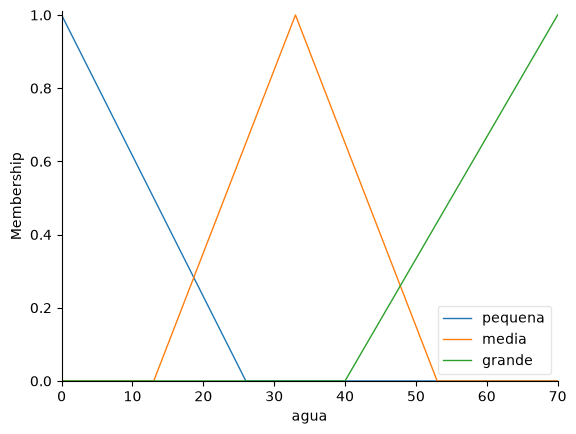

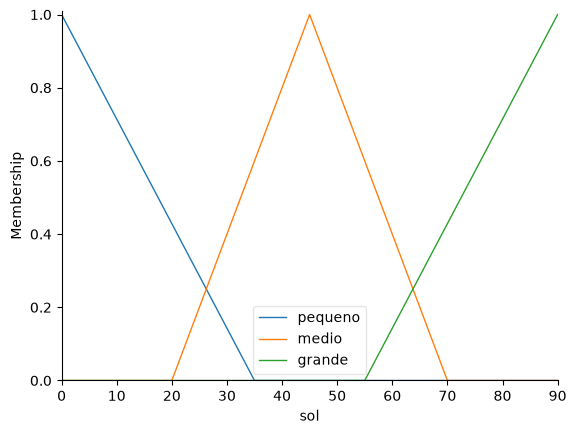

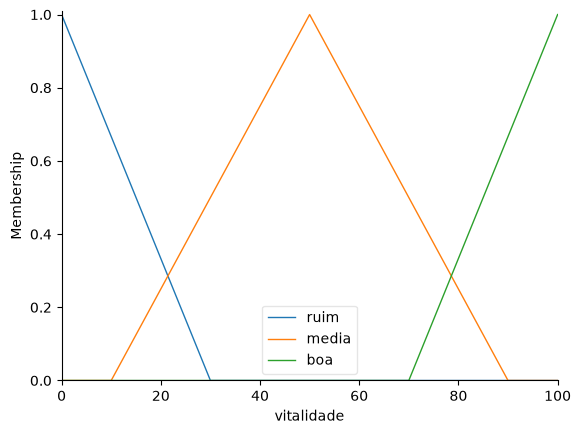

In [9]:
agua.view()
sol.view()
vitalidade.view()